<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/notebooks/02_ssdu_reconstruction_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git
%cd /content/reliability-aware-ssdu-mri

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 249 (delta 64), reused 16 (delta 16), pack-reused 142 (from 1)
Receiving objects: 100% (249/249), 1.47 MiB | 12.97 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/content/reliability-aware-ssdu-mri


In [3]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from fastmri_data import load_fastmri_file, get_kspace_slice
from ssdu import split_acquired_mask
from losses import expand_mask
from transforms import fft2c, ifft2c
from reconstruction import normalize_to_unit_range
from models import SimpleCNNReconstructor

print("Notebook 02 setup complete.")

Notebook 02 setup complete.


In [4]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

kspace_slice, slice_index = get_kspace_slice(data["kspace"])

mask = data["mask"]

print("Selected slice index:", slice_index)
print("K-space slice shape:", kspace_slice.shape)
print("Mask shape:", mask.shape)
print("Acquisition:", data["attrs"].get("acquisition"))
print("Acceleration:", data["attrs"].get("acceleration"))

Selected slice index: 8
K-space slice shape: (16, 768, 396)
Mask shape: (396,)
Acquisition: AXT2
Acceleration: 4


#**Convert multicoil data to a single-coil-equivalent slice**

In [5]:
# Select one coil for a single-coil-equivalent SSDU baseline
coil_index = 0

# Shape: height x width
kspace_single = kspace_slice[coil_index]

print("Selected coil index:", coil_index)
print("Single-coil k-space shape:", kspace_single.shape)
print("Single-coil k-space dtype:", kspace_single.dtype)

Selected coil index: 0
Single-coil k-space shape: (768, 396)
Single-coil k-space dtype: complex64


**Create SSDU split for single-coil k-space**

In [6]:
theta_mask, lambda_mask = split_acquired_mask(
    mask=mask,
    rho=0.4,
    seed=42
)

print("Original mask fraction:", np.mean(mask > 0))
print("Theta mask fraction:", np.mean(theta_mask > 0))
print("Lambda mask fraction:", np.mean(lambda_mask > 0))
print("Theta + Lambda equals original mask:", np.all((theta_mask + lambda_mask) == mask))

Original mask fraction: 0.25
Theta mask fraction: 0.14898989898989898
Lambda mask fraction: 0.10101010101010101
Theta + Lambda equals original mask: True


**Create Theta-only and Lambda-only single-coil k-space**

In [7]:
# Expand masks to match single-coil k-space shape: height x width
theta_mask_2d = theta_mask[None, :]
lambda_mask_2d = lambda_mask[None, :]

# Apply masks
kspace_theta_single = theta_mask_2d * kspace_single
kspace_lambda_single = lambda_mask_2d * kspace_single

print("Theta-only k-space shape:", kspace_theta_single.shape)
print("Lambda-only k-space shape:", kspace_lambda_single.shape)

print("Theta nonzero fraction:", np.mean(np.abs(kspace_theta_single) > 0))
print("Lambda nonzero fraction:", np.mean(np.abs(kspace_lambda_single) > 0))

Theta-only k-space shape: (768, 396)
Lambda-only k-space shape: (768, 396)
Theta nonzero fraction: 0.14898989898989898
Lambda nonzero fraction: 0.10101010101010101


In [8]:
#reconstruct the Theta-only input image:
# Theta-only zero-filled reconstruction
x_theta_complex = ifft2c(kspace_theta_single)

# Magnitude image for CNN input
x_theta_mag = np.abs(x_theta_complex)

# Normalize
x_theta_norm = normalize_to_unit_range(x_theta_mag)

print("Theta-only image shape:", x_theta_norm.shape)
print("Min:", x_theta_norm.min())
print("Max:", x_theta_norm.max())

Theta-only image shape: (768, 396)
Min: 0.0
Max: 1.0


**Visualize the single-coil SSDU input**

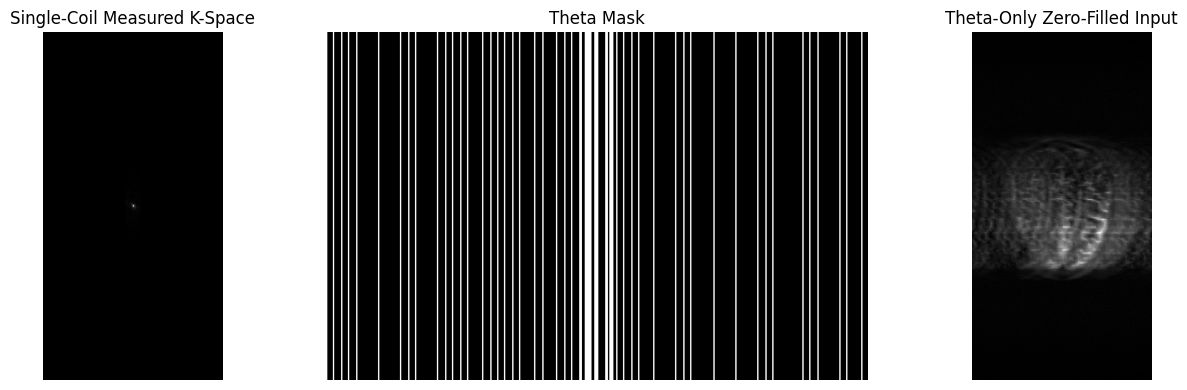

In [9]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.log1p(np.abs(kspace_single)), cmap="gray")
plt.title("Single-Coil Measured K-Space")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(theta_mask[None, :], cmap="gray", aspect="auto")
plt.title("Theta Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(x_theta_norm, cmap="gray")
plt.title("Theta-Only Zero-Filled Input")
plt.axis("off")

plt.tight_layout()
plt.show()

**PyTorch tensors for single-coil SSDU**

In [10]:
# Convert Theta-only input image to tensor
x_input = torch.from_numpy(x_theta_norm).float()
x_input = x_input.unsqueeze(0).unsqueeze(0)  # batch x channel x height x width

print("Input tensor shape:", x_input.shape)

# Convert measured single-coil k-space and Lambda mask to tensors later if needed
print("Single-coil k-space shape:", kspace_single.shape)
print("Lambda mask shape:", lambda_mask.shape)

Input tensor shape: torch.Size([1, 1, 768, 396])
Single-coil k-space shape: (768, 396)
Lambda mask shape: (396,)


**forward pass:**

In [11]:
model = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

model.train()

x_output = model(x_input)

print("Model output shape:", x_output.shape)

Model output shape: torch.Size([1, 1, 768, 396])


**Compute SSDU loss from the model output**

In [12]:
# Convert model output back to NumPy image
x_hat = x_output.detach().cpu().numpy()[0, 0]

# Convert predicted image to k-space
kspace_hat = fft2c(x_hat)

# Apply Lambda mask
lambda_mask_2d = lambda_mask[None, :]

pred_lambda = lambda_mask_2d * kspace_hat
true_lambda = lambda_mask_2d * kspace_single

# Compute normalized SSDU loss
numerator = np.sum(np.abs(pred_lambda - true_lambda) ** 2)
denominator = np.sum(np.abs(true_lambda) ** 2) + 1e-12

ssdu_loss_value = numerator / denominator

print("Predicted Lambda k-space shape:", pred_lambda.shape)
print("True Lambda k-space shape:", true_lambda.shape)
print("Single-coil SSDU loss:", ssdu_loss_value)

Predicted Lambda k-space shape: (768, 396)
True Lambda k-space shape: (768, 396)
Single-coil SSDU loss: 10917336.0


**Train the single-coil CNN for a few iterations**

In [13]:
import torch.optim as optim

# Reinitialize model for training
model = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Fixed input tensor
x_input = torch.from_numpy(x_theta_norm).float()
x_input = x_input.unsqueeze(0).unsqueeze(0)

# Prepare Lambda target in NumPy
lambda_mask_2d = lambda_mask[None, :]
true_lambda = lambda_mask_2d * kspace_single

loss_history = []

num_steps = 50

model.train()

for step in range(num_steps):
    optimizer.zero_grad()

    # Forward pass
    x_pred_tensor = model(x_input)

    # Convert output to NumPy for FFT-based SSDU loss
    x_pred = x_pred_tensor[0, 0]

    # Torch FFT version for differentiable training
    x_pred_complex = torch.complex(x_pred, torch.zeros_like(x_pred))

    k_pred = torch.fft.fftshift(
        torch.fft.fft2(
            torch.fft.ifftshift(x_pred_complex, dim=(-2, -1)),
            norm="ortho"
        ),
        dim=(-2, -1)
    )

    # Convert Lambda target and mask to torch tensors
    true_lambda_torch = torch.from_numpy(true_lambda).to(k_pred.device)
    lambda_mask_torch = torch.from_numpy(lambda_mask_2d).float().to(k_pred.device)

    # Complex residual on Lambda
    residual = lambda_mask_torch * (k_pred - true_lambda_torch)

    numerator = torch.sum(torch.abs(residual) ** 2)
    denominator = torch.sum(torch.abs(true_lambda_torch) ** 2) + 1e-12

    loss = numerator / denominator

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(f"Step {step:03d} | SSDU loss: {loss.item():.6f}")

Step 000 | SSDU loss: 10282251.000000
Step 010 | SSDU loss: 9801584.000000
Step 020 | SSDU loss: 9078919.000000
Step 030 | SSDU loss: 8059580.500000
Step 040 | SSDU loss: 6619286.000000
Step 049 | SSDU loss: 5179808.500000


**Plot the SSDU loss curve**

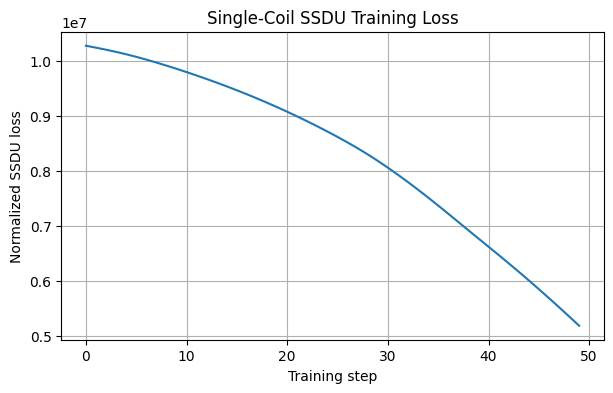

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Normalized SSDU loss")
plt.title("Single-Coil SSDU Training Loss")
plt.grid(True)
plt.show()

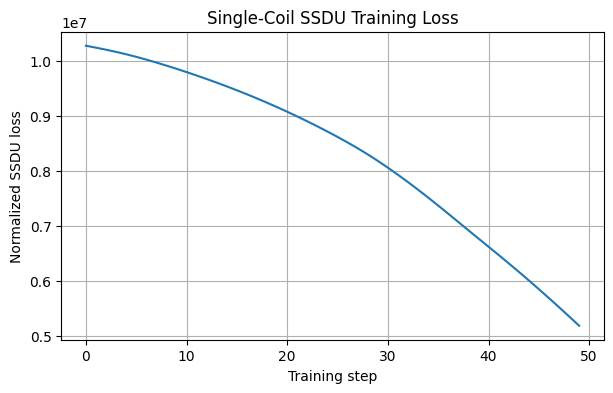

Initial loss: 10282251.0
Final loss: 5179808.5
Loss reduction: 5102442.5
Percentage reduction: 49.62378860426574


In [15]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Normalized SSDU loss")
plt.title("Single-Coil SSDU Training Loss")
plt.grid(True)
plt.show()

print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])
print("Loss reduction:", loss_history[0] - loss_history[-1])
print("Percentage reduction:", 100 * (loss_history[0] - loss_history[-1]) / loss_history[0])

**Visualize before and after training**

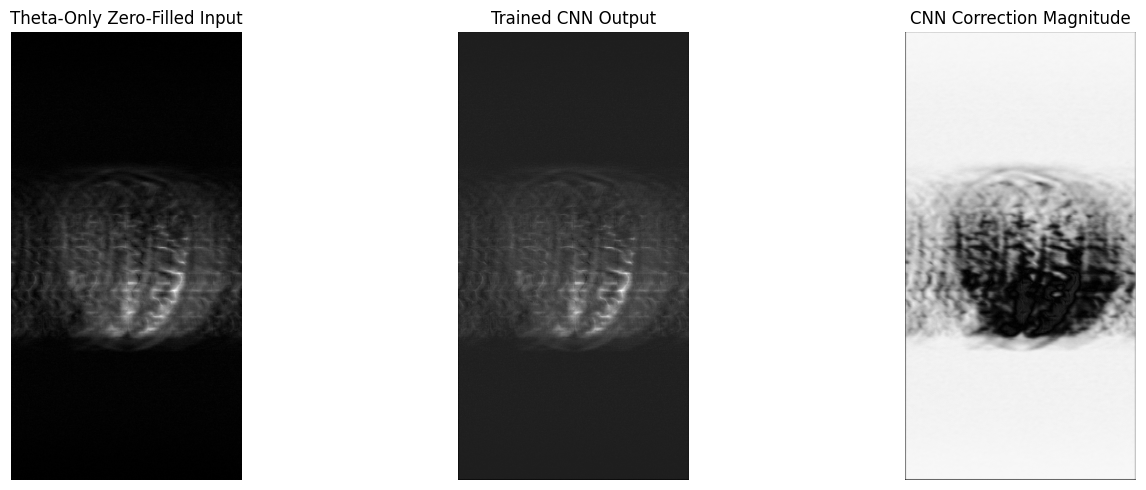

In [16]:
# Get final trained model output
model.eval()

with torch.no_grad():
    x_trained_tensor = model(x_input)

x_trained = x_trained_tensor.detach().cpu().numpy()[0, 0]
x_trained_norm = normalize_to_unit_range(x_trained)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_theta_norm, cmap="gray")
plt.title("Theta-Only Zero-Filled Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_trained_norm, cmap="gray")
plt.title("Trained CNN Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(x_trained_norm - x_theta_norm), cmap="gray")
plt.title("CNN Correction Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

**Add an image-consistency term**

In [18]:
model_reg2 = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

optimizer = optim.Adam(model_reg2.parameters(), lr=1e-4)

lambda_img = 1e7
num_steps = 50

loss_history_reg2 = []
ssdu_history_reg2 = []
img_history_reg2 = []

model_reg2.train()

for step in range(num_steps):
    optimizer.zero_grad()

    x_pred_tensor = model_reg2(x_input)
    x_pred = x_pred_tensor[0, 0]

    x_pred_complex = torch.complex(x_pred, torch.zeros_like(x_pred))

    k_pred = torch.fft.fftshift(
        torch.fft.fft2(
            torch.fft.ifftshift(x_pred_complex, dim=(-2, -1)),
            norm="ortho"
        ),
        dim=(-2, -1)
    )

    true_lambda_torch = torch.from_numpy(true_lambda).to(k_pred.device)
    lambda_mask_torch = torch.from_numpy(lambda_mask_2d).float().to(k_pred.device)

    residual = lambda_mask_torch * (k_pred - true_lambda_torch)

    numerator = torch.sum(torch.abs(residual) ** 2)
    denominator = torch.sum(torch.abs(true_lambda_torch) ** 2) + 1e-12

    ssdu_loss = numerator / denominator

    img_loss = torch.mean(torch.abs(x_pred_tensor - x_input))

    total_loss = ssdu_loss + lambda_img * img_loss

    total_loss.backward()
    optimizer.step()

    loss_history_reg2.append(total_loss.item())
    ssdu_history_reg2.append(ssdu_loss.item())
    img_history_reg2.append(img_loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(
            f"Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f}"
        )

Step 000 | Total: 10811510.000000 | SSDU: 10226644.000000 | Image: 0.058487
Step 010 | Total: 9865677.000000 | SSDU: 9324516.000000 | Image: 0.054116
Step 020 | Total: 8974507.000000 | SSDU: 8475865.000000 | Image: 0.049864
Step 030 | Total: 7916303.500000 | SSDU: 7453232.500000 | Image: 0.046307
Step 040 | Total: 6679839.500000 | SSDU: 6231861.000000 | Image: 0.044798
Step 049 | Total: 5435122.000000 | SSDU: 4972892.500000 | Image: 0.046223


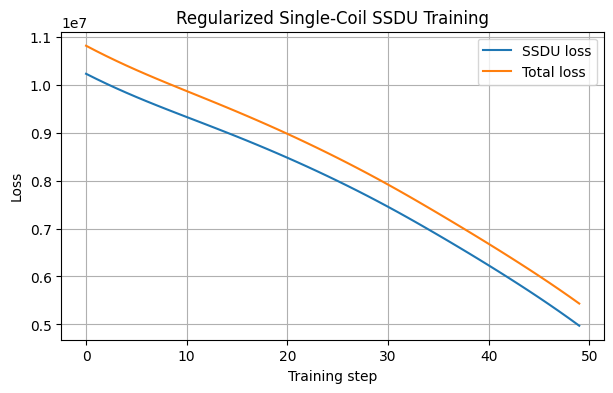

Initial SSDU loss: 10226644.0
Final SSDU loss: 4972892.5
SSDU reduction: 5253751.5
Percentage SSDU reduction: 51.373172861008946
Initial image loss: 0.05848659202456474
Final image loss: 0.046222951263189316


In [19]:
plt.figure(figsize=(7, 4))
plt.plot(ssdu_history_reg2, label="SSDU loss")
plt.plot(loss_history_reg2, label="Total loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Regularized Single-Coil SSDU Training")
plt.legend()
plt.grid(True)
plt.show()

print("Initial SSDU loss:", ssdu_history_reg2[0])
print("Final SSDU loss:", ssdu_history_reg2[-1])
print("SSDU reduction:", ssdu_history_reg2[0] - ssdu_history_reg2[-1])
print("Percentage SSDU reduction:", 100 * (ssdu_history_reg2[0] - ssdu_history_reg2[-1]) / ssdu_history_reg2[0])

print("Initial image loss:", img_history_reg2[0])
print("Final image loss:", img_history_reg2[-1])

**visualize the regularized output**

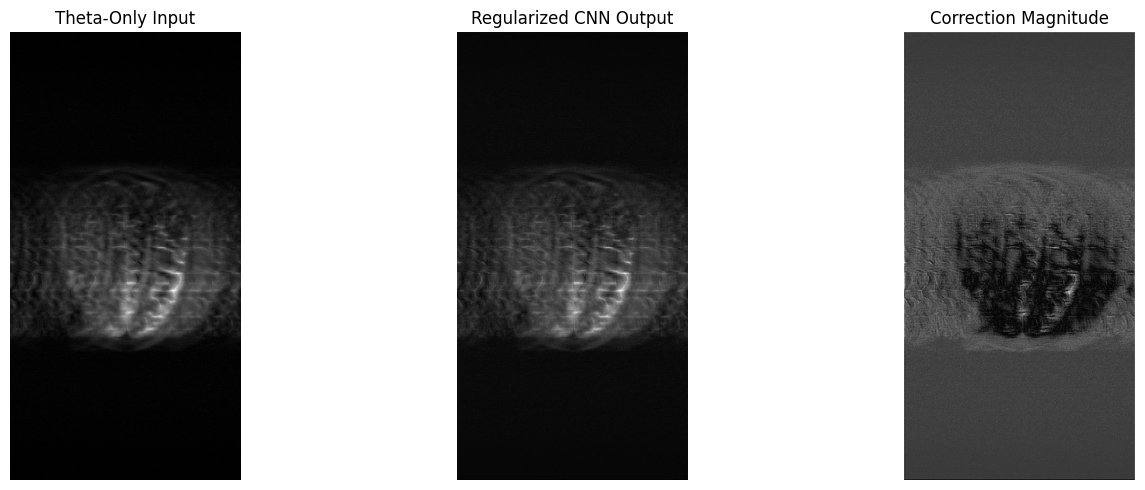

In [20]:
model_reg2.eval()

with torch.no_grad():
    x_reg2_tensor = model_reg2(x_input)

x_reg2 = x_reg2_tensor.detach().cpu().numpy()[0, 0]
x_reg2_norm = normalize_to_unit_range(x_reg2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_theta_norm, cmap="gray")
plt.title("Theta-Only Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_reg2_norm, cmap="gray")
plt.title("Regularized CNN Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(x_reg2_norm - x_theta_norm), cmap="gray")
plt.title("Correction Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()